# **Practice 16 - String Processing**

#### **Kelani Guyton**

---

**IMPORTANT**:
- Before starting the lab, save a copy to your google drive by navigating to `File > Save a copy in Drive` <br>

<br>


**Instructions**: Complete the lab below.

- <font color=red>Tasks</font> indicated in red must be completed to receive credit
- Include all code for your work
- Include markdown cells with written answers explaining your work when prompted
- **NOTE: Your completed lab must be submitted to Canvas as a .ipynb file by the end of the lab session**
---

<br>

####<font color=red>Organized</font>

**Answers should be organized in the following format for organization and readability**


<font color=red>Example task 1</font>

In [ ]:
# 1.

# This will be the code block to answer the first part of a task

1. This will be the text answer/explanation (if prompted) for the first task

<font color=red>Example task 2</font>

In [ ]:
# 2.

# This will be the code block to answer the second part of a task

2. This will be the text answer/explanation (if prompted) for the second task

<br>

Continue this format for the remaining subtasks


<br>

---

<br>

#### Packages

In [ ]:
# none!

<br>

<br>

<br>

---

####<font color=red>Task 1</font>

For today's practice assignment, we will clean and reorganize a set of strings containing movies titles, their genres, and their release dates.

We will analyze this data in the next lesson!


<font color=red>Task 1.1</font>

* Load the dataset on movies using the script below.

  ```movies <- read.csv("https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/movies.csv", header = FALSE)```

* Show the first few lines of the `movies` dataset using the `head()` function

In [1]:
# Load the dataset
movies <- read.csv("https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/movies.csv", header = FALSE)

# Show the first few rows
head(movies)


,V1
,<chr>
1,0000008::Edison Kinetoscopic Record of a Sneeze (1894)::Documentary|Short
2,0000010::La sortie des usines Lumière (1895)::Documentary|Short
3,0000012::The Arrival of a Train (1896)::Documentary|Short
4,25::The Oxford and Cambridge University Boat Race (1895)::
5,0000091::Le manoir du diable (1896)::Short|Horror
6,0000131::Une nuit terrible (1896)::Short|Comedy|Horror


<br>

<font color=red>Task 1.2</font>

* Use the `str()` function to determine the number of rows and columns in the data frame

In [2]:
# Show the structure of the dataset
str(movies)


'data.frame':	37342 obs. of  1 variable:
 $ V1: chr  "0000008::Edison Kinetoscopic Record of a Sneeze (1894)::Documentary|Short" "0000010::La sortie des usines Lumière (1895)::Documentary|Short" "0000012::The Arrival of a Train (1896)::Documentary|Short" "25::The Oxford and Cambridge University Boat Race (1895)::" ...


<br>

<font color=red>Task 1.3</font>

* What information about movies in contained within the data frame? Describe your observations in a text cell.

The data frame contains information about different movies. Each row represents a movie, and the columsn store variables describing the movies.

<br>

<font color=red>Task 1.4</font>

This is a lot of data! It's sometimes a good idea to work with a subset of your data (***at first***) when you have many observations, then you can expand you code to the entire datasets. <br>
Let's just work with the first 10 movies.

*  Extract the first 10 movies and store as a `character` vector in a variable named `movies10`


In [3]:
# Extract the first 10 movies
movies10 <- as.character(movies[1:10, 1])


<br>

<br>

<br>

---

####<font color=red>Task 2</font> - Correcting movies with no genre


<font color=red>Task 2.1</font>

* Use `nchar()` to determine the length of each string in the character vector `movies10`

In [4]:
nchar(movies10)

[1] 73 63 57 58 49 54 80 67 51 54

<br>

<font color=red>Task 2.2</font>

* Use `substring()` and `nchar()` to extract the last two characters in each movie description

  Hint: `substring(movies10, 1, 2)` extracts the first two characters, but we want the last two characters)

* Store your result as the variable `last_two`

In [5]:
last_two <- substring(movies10, nchar(movies10) - 1, nchar(movies10))

<br>

<font color=red>Task 2.3</font>

If the last two characters in a string are `"::"`, this means there is no genre specified for that movie. In this case, let's insert a `"None"` if there are no specified genres.

* Use `which()` to determine which strings end with two colons `"::"`

In [6]:
which(last_two == "::")

[1] 4 9

<br>

<font color=red>Task 2.4</font>

Use your answer to Task 2.3 to subset the entries where the last two characters are `"::"`

In [7]:
movies10[which(last_two == "::")]

[1] "25::The Oxford and Cambridge University Boat Race (1895)::"
[2] "0443::Hiawatha, the Messiah of the Ojibway (1903)::"

<br>

<font color=red>Task 2.5</font>

* Using `paste0`, concatenate the string `"None"` to all of the movies that end with two colons `"::"`

  For example, the fourth movie will change from

  ```"25::The Oxford and Cambridge University Boat Race (1895)::"```

  to
  
  ```"25::The Oxford and Cambridge University Boat Race (1895)::None"```


In [8]:
movies10[which(last_two == "::")] <- paste0(movies10[which(last_two == "::")], "None")

<br>

<font color=red>Task 2.6</font>

* Overwrite the original movies with the result from Task 2.5.

  Hint: `movies10[which(...)] <- paste0(...)`

In [9]:
movies10[which(last_two == "::")] <- paste0(movies10[which(last_two == "::")], "None")

<br>

<br>

<br>

---

####<font color=red>Task 3</font> - Extracting meaningful data fields from movie text


<font color=red>Task 3.1</font>

Each meaningful data field is separated by two colons `"::"`

* Use `strsplit()` to split each string by the pattern `"::"`

* What do you observe from the output? What is the `class()` of the output?


In [10]:
split_movies <- strsplit(movies10, "::")
class(split_movies)

[1] "list"

The output shows that each string is split into multiple pieces using `::` as a separator. The output is a 'list' where each element contains the separated field for one movie.

<br>

<font color=red>Task 3.2</font>

* Use `do.call()` to row bind each list item into a single data frame. If the output is matrix, be sure to convert it to a data frame and store as the variable `movies_clean`

  Hint: `do.call(rbind, output from Task 3.1)`

* Rename each column to `"movie_id"`, `"movie"`, `"genre"`

Your result should appear as follows:

In [11]:
# Bind the list into a matrix, then convert to data frame
movies_clean <- as.data.frame(do.call(rbind, split_movies))

# Rename the columns
colnames(movies_clean) <- c("movie_id", "movie", "genre")


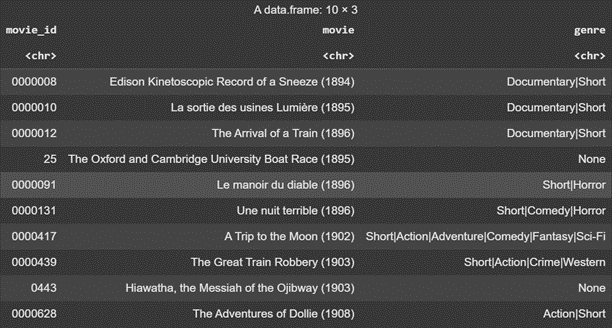

<br>

<font color=red>Task 3.3</font>

* Extract the year of each movie from the `movie` column

  Hint: Use `nchar()` and `substring()`

* Store the result as the variable `year` in your `movies_clean` data frame

Your result should appear as follows:

In [12]:
movies_clean$year <- substring(movies_clean$movie,
                               nchar(movies_clean$movie) - 4,
                               nchar(movies_clean$movie) - 1)

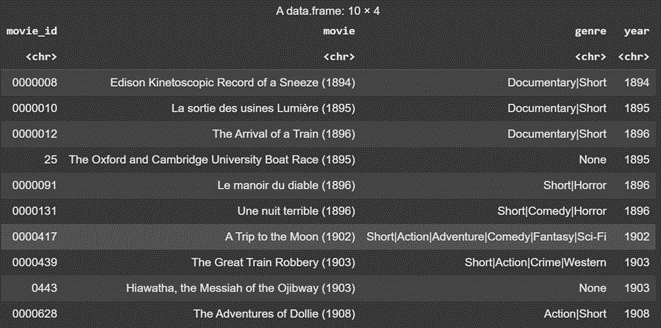

<br>

<font color=red>Task 3.4</font>

* Remove the year of each movie from the `movie` column. For example, the movie

  `Edison Kinetoscopic Record of a Sneeze (1894)` should now be

  `Edison Kinetoscopic Record of a Sneeze`

  Hint: Again, use `nchar()` and `substring()`

In [13]:
movies_clean$movie <- substring(movies_clean$movie, 1, nchar(movies_clean$movie) - 7)

<br>

<font color=red>Task 3.5</font>

* Overwrite your `movie` column with this result

Your result should appear as follows:

In [14]:
movies_clean$movie <- substring(movies_clean$movie, 1, nchar(movies_clean$movie) - 7)

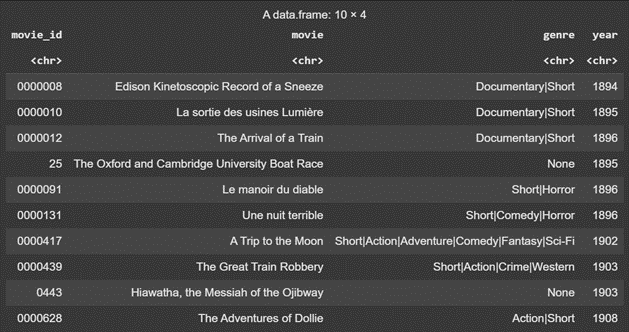

<br>

<br>

<br>

---

####<font color=red>Task 4</font> - Formatting the genres


<font color=red>Task 4.1</font>

* Use `gsub()` to replace all vertical bars `"\\|"` in the `genre` column to a comma and space `", "`

  Note that the vertical bar needs the escape backslash!

* Overwrite the `genre` column with your result

In [15]:
movies_clean$genre <- gsub("\\|", ", ", movies_clean$genre)

<br>

<font color=red>Task 4.2</font>

* Use `tolower()` to convert all genres to lower case

* Overwrite the `genre` column with your result

In [16]:
movies_clean$genre <- tolower(movies_clean$genre)

<br>

<font color=red>Task 4.3</font>

* Create a new data frame from the `movies_clean` data frame with the following columns
  * `movie`
  * `year`
  * `genre`

  Note that `movie_id` is being removed

  Your result should appear as follows:


In [17]:
movies_clean <- movies_clean[, c("movie", "year", "genre")]

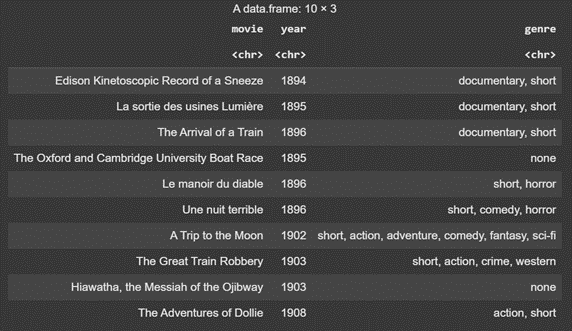

<br>

<br>

<br>

---

####<font color=red>Task 5 (Optional)</font> - Formatting the genres


<font color=red>Task 5.1</font>

Thus far, we have only clean the first 10 movies in the dataset.

* Repeat the previous steps to clean the entire movies dataset.